In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [2]:
atoms = 2000
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
angle = 0.3 #radians
sinangle = math.sin(angle)
cosangle = math.cos(angle)
thermsteps = 801
velarr = np.array([1e2,1e3,1e4,1e5,1e6,1e7,1e8])
casearr = np.array([0,1,2,3])
folder = "../dataarchive/run10_8"

def trajtoarr(filename, dt,atoms=2000):
    timeflag =False
    atomflag=False
    count = 0
    atomlist = []
    tempatomlist=[]
    timestep=0
    with open(filename, 'r') as file:
        for line in file:
            if "ITEM" in line:
                if "ITEM: TIMESTEP" in line:
                    count += 1
                    timeflag = True
                    atomflag=False
                    tempatomlist.append(float(dt*timestep))
                    atomlist.append(tempatomlist)
                    tempatomlist=[]
                elif "ITEM: ATOMS id type vx vy vz" in line:
                    atomflag = True
                    timeflag=False
                else:
                    timeflag = False
                    atomflag = False
            if timeflag and ("ITEM" not in line):
                timestep = float(line.strip())
            if atomflag and ("ITEM" not in line):
                vz = float(line.strip().split(" ")[-1])
                vy = float(line.strip().split(" ")[-2])
                tempatomlist.append(sinangle*vy+cosangle*vz)
                count += 1
    tempatomlist.append(float(dt*timestep))
    atomlist.append(tempatomlist)
    atomlist.pop()
    atomlist.pop(0)
    atomlist.pop()
    atomarr = np.array(atomlist)
    return atomarr
def logtoarr(filename):
    startlogstr = "   Step          Time           Temp         c_tempH        c_tempSi        TotEng         PotEng         KinEng         Press           v_k0           v_dt        v_collfreq       v_ccs "
    endlogstr = "Loop time of "
    templist=[]
    dataflag=False
    with open(filename, 'r') as file:
        for line in file:
            if dataflag:
                dataline = list(filter(None, line.split(" ")))
                dataline[-1] = dataline[-1][:-1]
                dataline = list(filter(None, dataline))
                templist.append(dataline)
            if startlogstr in line:
                dataflag=True
                templist=[]
            if endlogstr in line:
                dataflag=False

    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop(0)    # print(templist)
    return np.array(templist,dtype=np.float64)
for i in range(len(velarr)):
    for j in range(len(casearr)):
        if  [i,j] not in [[5,0],[2,0]]:
            print(i,j)
            vel = velarr[i]
            case = casearr[j]
            datai = logtoarr(folder+"/unforcedslumlogvel_v{:.1e}_c{}.txt".format(vel,case))
            dt = (datai[1,1]-datai[0,1])/100
            trajarr = trajtoarr(folder+"/trajvel_v{:.1e}_c{}.txt".format(vel,case),dt,atoms=atoms)
            np.savetxt("log_v{:.1}_c{}.np".format(vel,case),datai)
            np.savetxt("force_v{:.1}_c{}.np".format(vel,case),trajarr)





0 0
0 1
0 2
0 3
1 0
1 1
1 2
1 3
2 1
2 2
2 3
3 0
3 1
3 2
3 3
4 0
4 1
4 2
4 3
5 1
5 2
5 3
6 0
6 1
6 2
6 3


# Plot Temp and Energy over time

TypeError: only integer scalar arrays can be converted to a scalar index

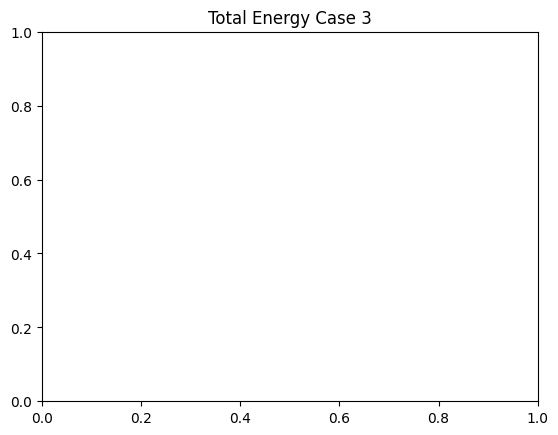

In [3]:
from matplotlib import cm
for j in range(len(casearr)):
    colors = cm.rainbow(np.linspace(0, 1, len(velarr)))
    plt.title("Total Energy Case {}".format(case))
    for i in range(velarr):
        plt.plot(datalist[i][:,0],np.abs(datalist[i][:,1]/datalist[i][0,1]-1),color=colors[i],label="v={:.1e}".format(varr[i]))
    plt.legend()
    plt.xlabel("Time (s)")
    plt.yscale("log")
    plt.ylabel("Fractional Change in Energy")
    plt.show()


# plot 

3 0
100000.0
2
24


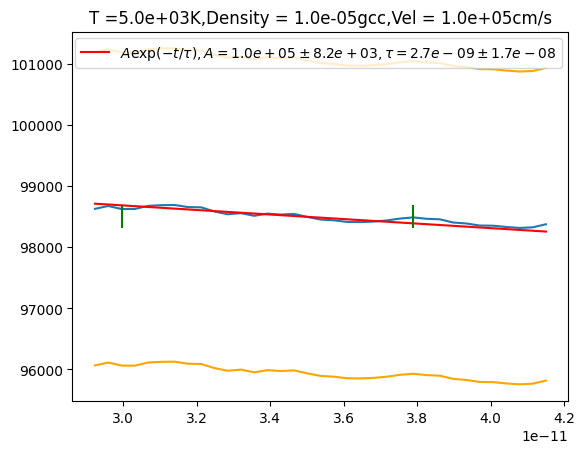

3 1
100000.0
0
7


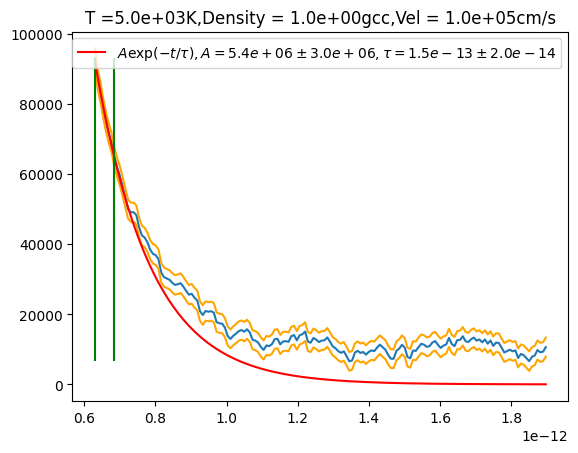

3 2
100000.0
0
36


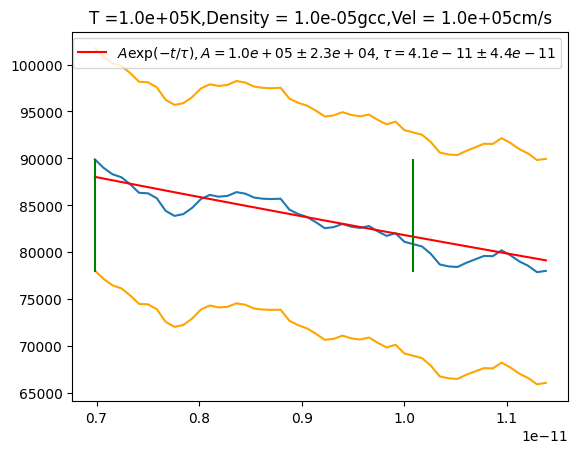

3 3
100000.0
0
11


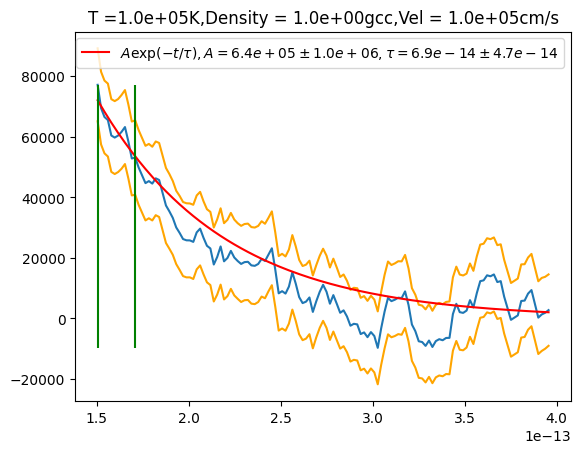

4 0
1000000.0
3
53


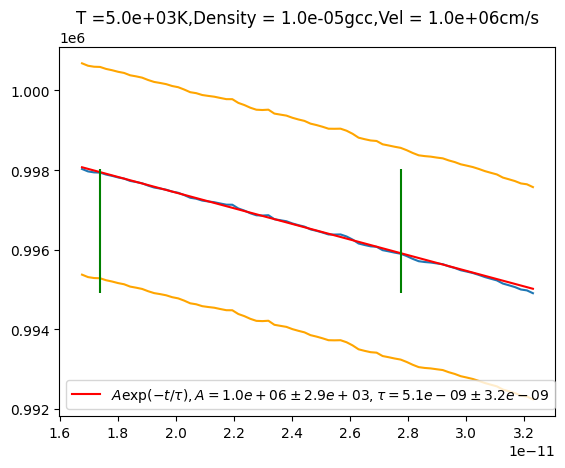

4 1
1000000.0
0
9


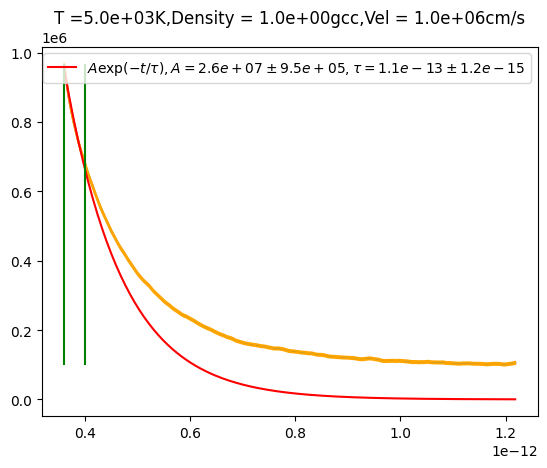

4 2
1000000.0
0
67


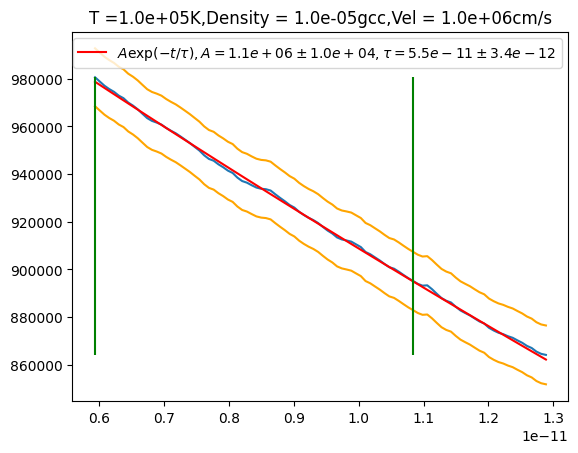

4 3
1000000.0
0
12


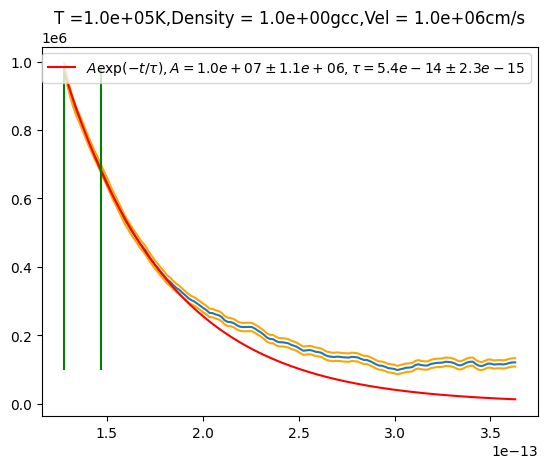

5 1
10000000.0
0
52


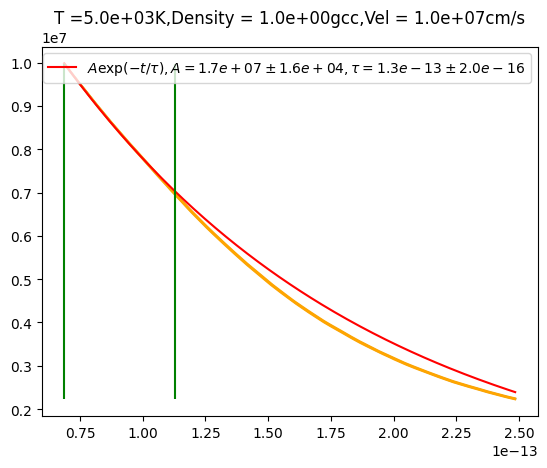

5 2
10000000.0
1
143


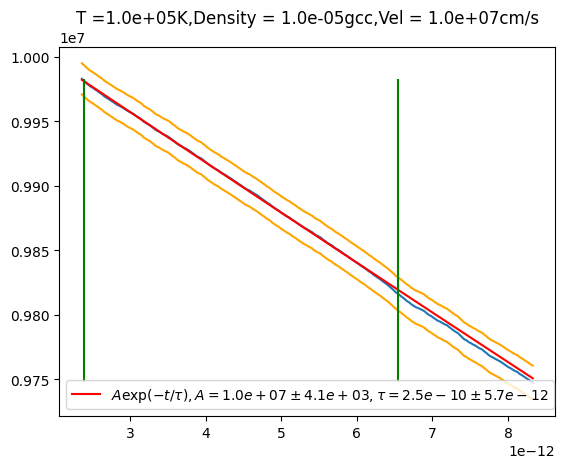

5 3
10000000.0
0
31


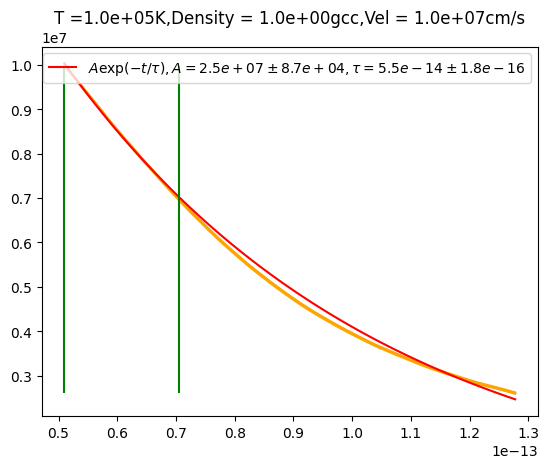

6 0
100000000.0
73
171


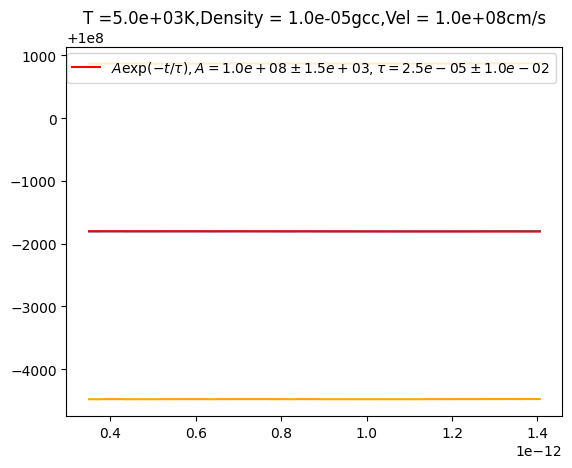

6 1
100000000.0
5
169


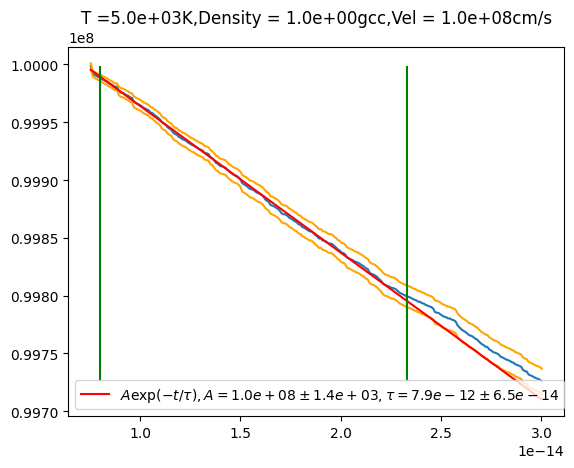

6 2
100000000.0
72
169


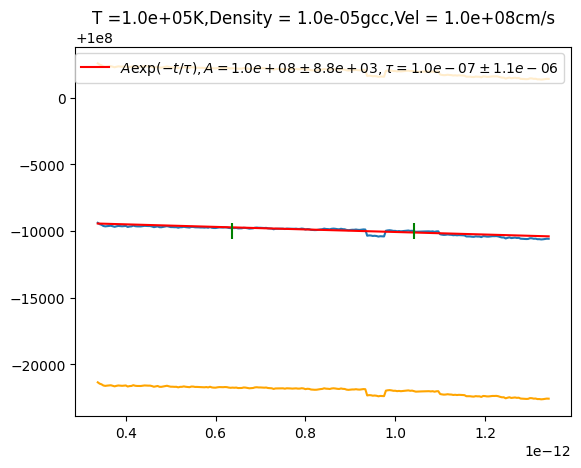

6 3
100000000.0
1
164


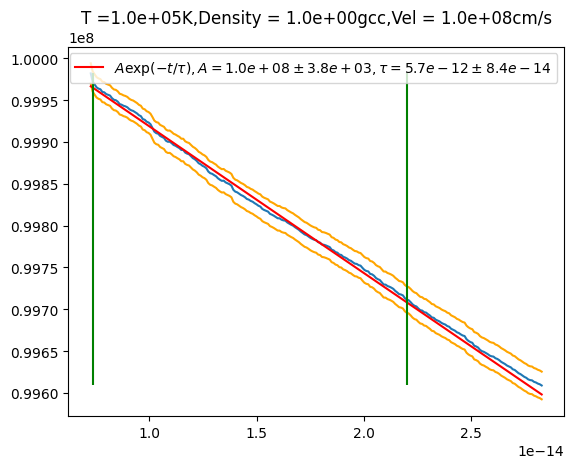

In [4]:
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
from scipy.optimize import curve_fit

results = -1*np.ones((4,len(velarr),6)) #4 cases, velocities, A, Aerr, tau, tauerr, start time, end time
def exp(time,m,b):
    return b*np.exp(-time/m)
for i in range(3,len(velarr)):
    for j in range(len(casearr)):
        if  [i,j] not in [[5,0],[2,0]]:
            print(i,j)
            vel = velarr[i]
            print(vel)
            case = casearr[j]
            log = np.loadtxt("log_v{:.1}_c{}.np".format(vel,case))
            force = np.loadtxt("force_v{:.1}_c{}.np".format(vel,case))

            time = force[81:,-1]
            data = force[81:,:-1]
            plt.title("T ={:.1e}K,Density = {:.1e}gcc,Vel = {:.1e}cm/s".format(Tarr[j],gccarr[j],velarr[i]))
            mean = np.mean(data,axis=1)

            starti = min(np.argmin(np.abs(0.9999*mean[0]-mean)),int(0.3*len(mean)))
            print(starti)
            endi = min(np.argmin(np.abs(0.7*mean[0]-mean)),int(0.7*len(mean)))
            std = np.std(data,axis=1)/math.sqrt(2000)
            dt0 = time[-1]-time[0]
            plt.plot(time,mean)
            print(endi)
            popt, pcov = curve_fit(exp,time[starti:endi],mean[starti:endi],sigma =std[starti:endi],p0=[dt0,mean[0]*math.exp(-time[0]/dt0)],absolute_sigma=True)
            errors = np.sqrt(np.diag(pcov))
            results[j,i,:] = [popt[1],errors[1],popt[0],errors[0],time[starti],time[endi]]
            plt.plot(time,mean+std,color="orange")
            plt.plot(time,mean-std,color="orange")
            plt.plot(time,exp(time,popt[0],popt[1]),color="red",label=r"$A\exp(-t/\tau),A = {:.1e}\pm{:.1e}, \tau = {:.1e}\pm {:.1e}$".format(popt[1],errors[1],popt[0],errors[0]))
            plt.vlines([time[starti],time[endi]],ymin=np.min(mean),ymax=np.max(mean),color="green")
            plt.legend()
            plt.show()
np.save("results",results)

$$ v = A \exp(-t/\tau)$$
$$ a = -v/\tau$$
$$(\Delta v)^2 = \exp(-2t/\tau) (\Delta A^2) + \frac{t^2A^2}{\tau^4} \exp(-2t/\tau) (\Delta \tau^2)$$
$$(\Delta v)^2 = \frac{v^2}{A^2} (\Delta A^2) + \frac{t^2v^2}{\tau^4}  (\Delta \tau^2)$$
$$(\frac{\Delta A}{A})^2 = (\frac{\Delta v}{v})^2 + (\frac{\Delta \tau}{\tau})^2$$

# Overall Plot

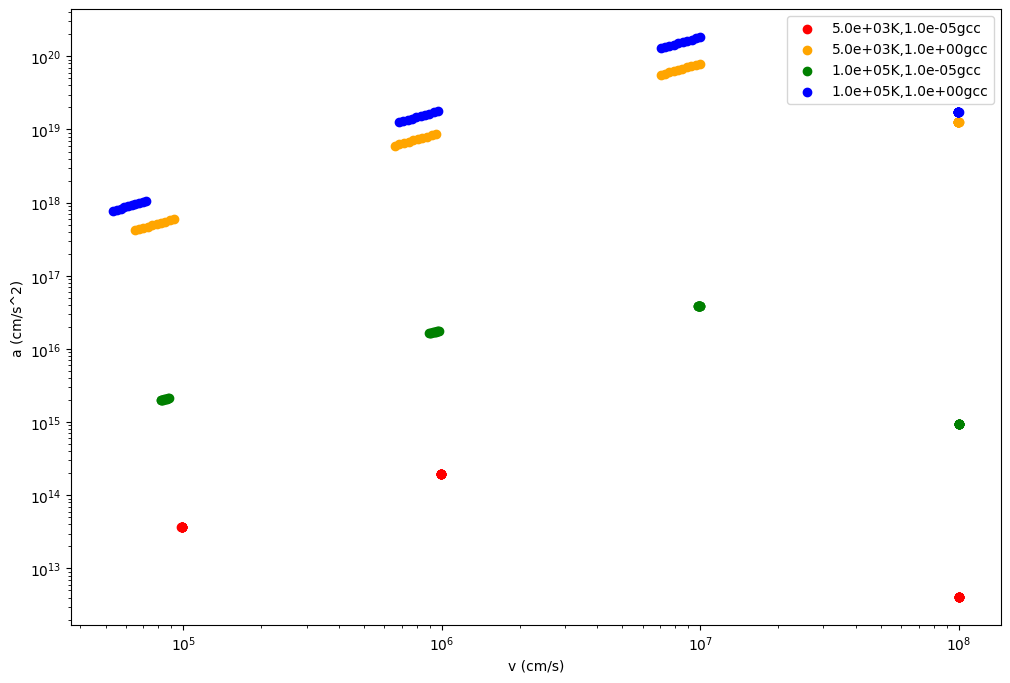

In [14]:
results = np.load("results.npy")
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
plt.figure(figsize=(12,8))
def exp(time,tau,A):
    return A*np.exp(-time/tau)
colors=["red","orange","green","blue"]
labelled = [False,False,False,False]
for i in range(4):
    for j in range(3,len(velarr)):
        if results[i,j,4] !=-1:
            casen = casearr[i]
            vel = velarr[j]
            startt = results[i,j,4]
            endt = results[i,j,5]
            tarr = np.linspace(startt,endt,10)
            A = results[i,j,0]
            eA = results[i,j,1]
            tau = results[i,j,2]
            etau = results[i,j,3]
            varr = exp(tarr,tau,A)
            aarr = varr/tau
            if labelled[i]:
                plt.scatter(varr,aarr,color=colors[i])
            else:
                plt.scatter(varr,aarr,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
                labelled[i] = True
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()